## 1: Import Libraries
We import all tools needed for feature fusion.
- pandas: to load and merge CSV feature tables
- numpy: for data handling
- matplotlib and seaborn: for visualization

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print("All libraries imported!")

All libraries imported!


## 2: Load All Feature Tables
We load the 3 feature CSV files:
- ECG HRV features: 6 features extracted from heartbeat intervals
- EEG band power features: 9 features extracted from brain waves
- Respiratory features: 7 features extracted from breathing signal
We also load the CNN probabilities saved from Day 4.
All tables have 2754 rows — one per 30-second window.

In [14]:
EMAN_PATH = r"C:\Users\EmaSk\Desktop\sleep-apnea-detection\eman"
AMNA_PATH = r"C:\Users\EmaSk\Desktop\mit-bih-data"

# Load ECG HRV features (Eman - Day 3)
df_ecg = pd.read_csv(f"{EMAN_PATH}\\ecg_hrv_features.csv")

# Load CNN probabilities (Eman - Day 4)
cnn_probs = np.load(f"{EMAN_PATH}\\cnn_probs.npy")

print(f"ECG HRV features loaded  : {df_ecg.shape}")
print(f"CNN probabilities loaded  : {cnn_probs.shape}")
print(f"\nECG columns: {list(df_ecg.columns)}")

ECG HRV features loaded  : (2754, 7)
CNN probabilities loaded  : (2754,)

ECG columns: ['mean_rr', 'sdnn', 'rmssd', 'mean_hr', 'pnn50', 'lf_hf_ratio', 'label']


## 3: Load Amna's Feature Tables
We load the EEG and respiratory feature tables that
Amna extracted on Days 3 and 4. These are saved as
CSV files downloaded from Google Drive.

In [15]:
# Load EEG band power features (Amna - Day 3)
df_eeg = pd.read_csv(f"{AMNA_PATH}\\eeg_band_features.csv")

# Load Respiratory features (Amna - Day 4)
df_resp = pd.read_csv(f"{AMNA_PATH}\\resp_features.csv")

print(f"EEG features loaded       : {df_eeg.shape}")
print(f" Respiratory features loaded: {df_resp.shape}")
print(f"\nEEG columns : {list(df_eeg.columns)}")
print(f"\nResp columns: {list(df_resp.columns)}")

EEG features loaded       : (2754, 10)
 Respiratory features loaded: (2754, 8)

EEG columns : ['delta_power', 'theta_power', 'alpha_power', 'beta_power', 'rel_delta', 'rel_theta', 'rel_alpha', 'rel_beta', 'delta_beta_ratio', 'label']

Resp columns: ['breathing_rate', 'mean_amplitude', 'std_amplitude', 'mean_peak_dist', 'breath_regularity', 'apnea_index', 'ie_ratio', 'label']


## 4: Merge All Features into One Table
We combine all features from ECG, EEG, respiratory signals
and CNN probabilities into one single feature table.
This multi-modal fusion is the core contribution of our project.
Final table will have:
- 6 ECG HRV features
- 1 CNN probability feature
- 9 EEG band power features
- 7 Respiratory features
= 23 features total per window

In [16]:
# Drop label column from EEG and Resp (keep only from ECG)
df_eeg_features  = df_eeg.drop(columns=['label'])
df_resp_features = df_resp.drop(columns=['label'])
df_ecg_features  = df_ecg.drop(columns=['label'])

# Add CNN probability as a feature
df_ecg_features['cnn_prob'] = cnn_probs

# Merge all together
df_merged = pd.concat([df_ecg_features, df_eeg_features, df_resp_features], axis=1)

# Add label back
df_merged['label'] = df_ecg['label'].values

print(f"Feature fusion complete!")
print(f"Total windows  : {len(df_merged)}")
print(f"Total features : {len(df_merged.columns) - 1}")
print(f"Normal windows : {np.sum(df_merged['label']==0)}")
print(f"Apnea windows  : {np.sum(df_merged['label']==1)}")
print(f"\nAll columns:")
for i, col in enumerate(df_merged.columns):
    print(f"  [{i+1}] {col}")

Feature fusion complete!
Total windows  : 2754
Total features : 23
Normal windows : 2389
Apnea windows  : 365

All columns:
  [1] mean_rr
  [2] sdnn
  [3] rmssd
  [4] mean_hr
  [5] pnn50
  [6] lf_hf_ratio
  [7] cnn_prob
  [8] delta_power
  [9] theta_power
  [10] alpha_power
  [11] beta_power
  [12] rel_delta
  [13] rel_theta
  [14] rel_alpha
  [15] rel_beta
  [16] delta_beta_ratio
  [17] breathing_rate
  [18] mean_amplitude
  [19] std_amplitude
  [20] mean_peak_dist
  [21] breath_regularity
  [22] apnea_index
  [23] ie_ratio
  [24] label


## 5: Visualize Feature Correlation Heatmap
We plot a correlation heatmap showing how all 23 features
relate to each other and to the label.
Features highly correlated with the label are the most
useful for predicting apnea.

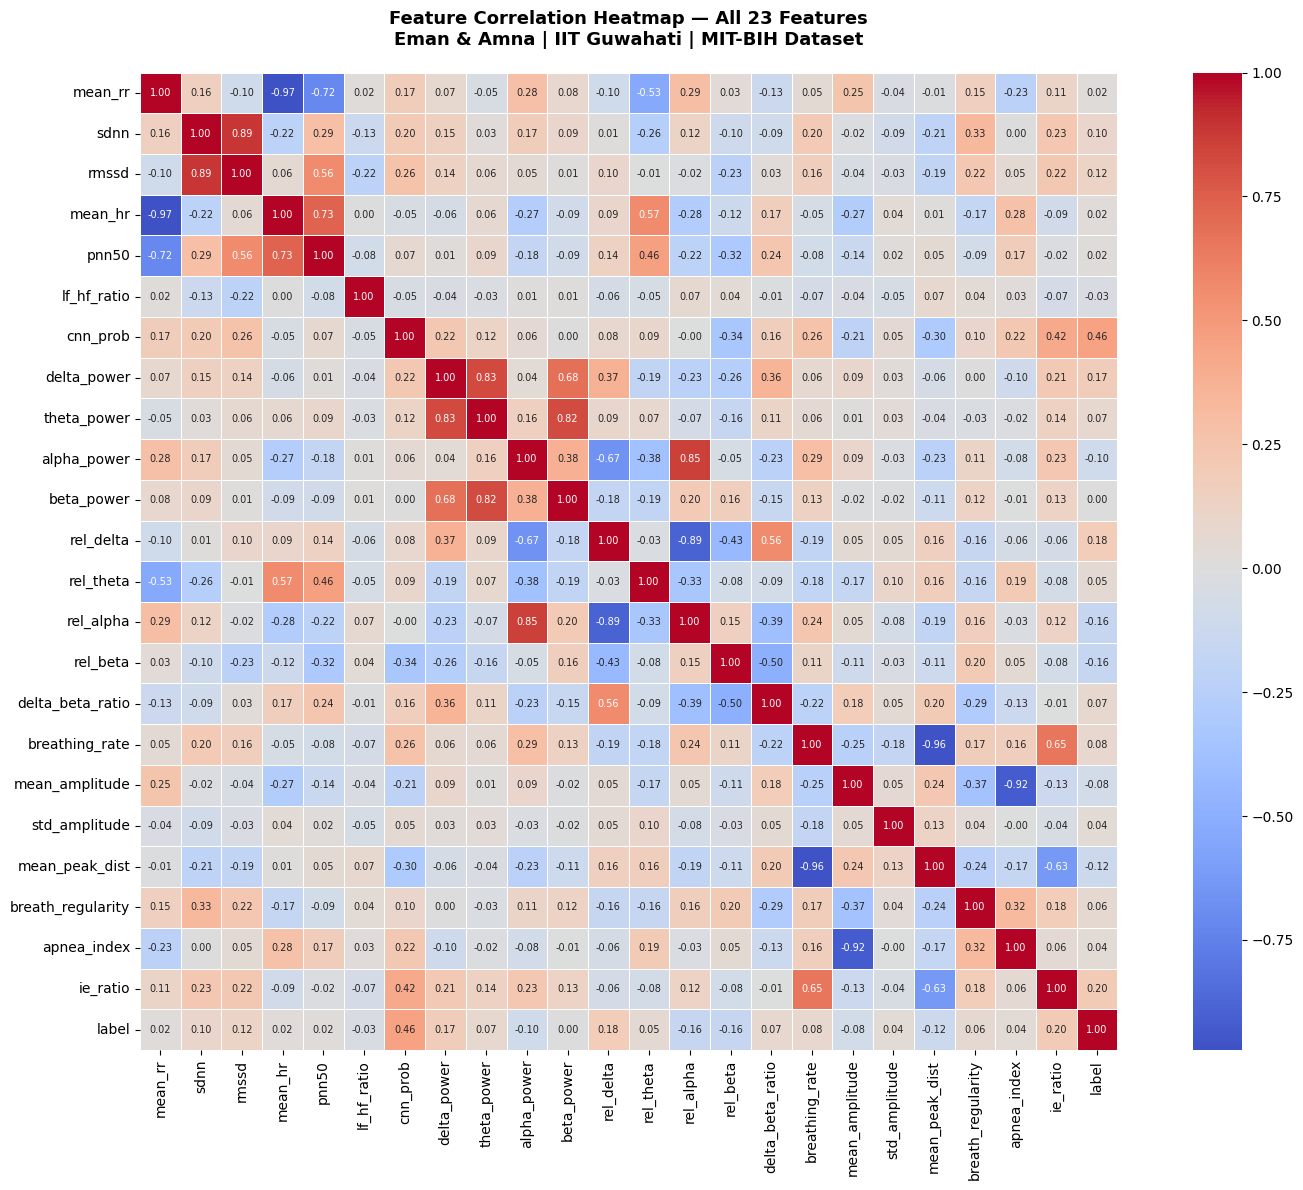

Heatmap saved


In [17]:
fig, ax = plt.subplots(figsize=(16, 12))
correlation = df_merged.corr()

sns.heatmap(correlation, 
            annot=True, 
            fmt='.2f', 
            cmap='coolwarm',
            center=0,
            square=True,
            linewidths=0.5,
            annot_kws={'size': 7},
            ax=ax)

ax.set_title("Feature Correlation Heatmap — All 23 Features\nEman & Amna | IIT Guwahati | MIT-BIH Dataset",
             fontsize=13, fontweight='bold', pad=20)

plt.tight_layout()
plt.savefig(r"C:\Users\EmaSk\Desktop\sleep-apnea-detection\eman\feature_correlation_heatmap.png",
            dpi=150, bbox_inches='tight')
plt.show()
print("Heatmap saved")

## 6: Save the Final Merged Feature Table
We save the complete merged table as a CSV file.
This is the final dataset that will be used on Day 6
for training Random Forest and XGBoost models.
2754 windows × 23 features + 1 label column.

In [18]:
SAVE_PATH = r"C:\Users\EmaSk\Desktop\sleep-apnea-detection\eman"

df_merged.to_csv(f"{SAVE_PATH}\\merged_features.csv", index=False)

print(f"Merged feature table saved")
print(f"File  : merged_features.csv")
print(f"Shape : {df_merged.shape}")

Merged feature table saved
File  : merged_features.csv
Shape : (2754, 24)
